# Wrangling

In [2]:
# load packages
library(tidyverse)

In [6]:
#load data
data(penguins)
data(iris)
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome, HomeOwn, Work, BMICatUnder20yrs, BMI_WHO, Diabetes, HealthGen, ...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Length, HeadCirc, Height, BMI, Pulse, BPSysAve, BPDiaAve, BPSys1, BPDi...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Exploring data

In [9]:
penguins |> glimpse()

Rows: 344
Columns: 8
$ species     <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Ade…
$ island      <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, Torgersen, To…
$ bill_len    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, 42.0, 37.8, 37.8, 41.1, 38.6, 34.6, 36.6, 38.7, 42.5, 34.4, 46.0, 37.8,…
$ bill_dep    <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, 20.2, 17.1, 17.3, 17.6, 21.2, 21.1, 17.8, 19.0, 20.7, 18.4, 21.5, 18.3,…
$ flipper_len <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186, 180, 182, 191, 198, 185, 195, 197, 184, 194, 174, 180, 189, 185, 180,…
$ body_mass   <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, 4250, 3300, 3700, 3200, 3800, 4400, 3700, 3450, 4500, 3325, 4200, 3400,…
$ sex         <fct> male, female, female, NA, female, male, female, male, NA, NA, NA, NA, female, male, male,

In [20]:
#exploring missingness
penguins |> is.na() |> colSums() |> as.data.frame()

            colSums(is.na(penguins))
species                            0
island                             0
bill_len                           2
bill_dep                           2
flipper_len                        2
body_mass                          2
sex                               11
year                               0

In [21]:
nhanes |> glimpse()

Rows: 20,293
Columns: 78
$ ID               <dbl> 51624, 51625, 51626, 51627, 51628, 51629, 51630, 51631, 51632, 51633, 51634, 51635, 51636, 51637, 51638, 51639, 51640,…
$ SurveyYr         <chr> "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10", "2009_10…
$ Gender           <chr> "male", "male", "male", "male", "female", "male", "female", "female", "male", "male", "male", "male", "male", "female"…
$ Age              <dbl> 34, 4, 16, 10, 60, 26, 49, 1, 10, 80, 10, 80, 4, 35, 9, 4, 17, 13, 7, 42, 0, 66, 8, 45, 28, 8, 11, 19, 1, 44, 66, 49, …
$ AgeMonths        <dbl> 409, 49, 202, 131, 722, 313, 596, 12, 124, NA, 121, NA, 48, 431, 115, 58, 208, 156, 85, 514, 9, 795, 101, 541, 338, 10…
$ Race1            <chr> "White", "Other", "Black", "Black", "Black", "Mexican", "White", "White", "Hispanic", "White", "Mexican", "White", "Ot…
$ Race3            <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, 

### Dealing with columns

In [ ]:
#select columns
nhanes |> 
  select(Age, Gender, Race1, Education, Weight, Height, BPDiaAve, BPSysAve)

# A tibble: 20,293 × 8
     Age Gender Race1    Education      Weight Height BPDiaAve BPSysAve
   <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl>    <dbl>    <dbl>
 1    34 male   White    High School      87.4   165.       85      113
 2     4 male   Other    NA               17     105.       NA       NA
 3    16 male   Black    NA               72.3   181.       59      109
 4    10 male   Black    NA               39.8   148.       41       93
 5    60 female Black    High School     117.    166        68      150
 6    26 male   Mexican  9 - 11th Grade   97.6   173        49      104
 7    49 female White    Some College     86.7   168.       75      112
 8     1 female White    NA                9.4    NA        NA       NA
 9    10 male   Hispanic NA               26     140.       53      108
10    80 male   White    Some College     79.1   174.       43      139
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [24]:
#renaming columns on the fly while selecting
nhanes |> 
  select(Age, Sex=Gender, Race=Race1, Education, Weight, Height, Diastolic=BPDiaAve, Systolic=BPSysAve)

# A tibble: 20,293 × 8
     Age Sex    Race     Education      Weight Height Diastolic Systolic
   <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl>     <dbl>    <dbl>
 1    34 male   White    High School      87.4   165.        85      113
 2     4 male   Other    NA               17     105.        NA       NA
 3    16 male   Black    NA               72.3   181.        59      109
 4    10 male   Black    NA               39.8   148.        41       93
 5    60 female Black    High School     117.    166         68      150
 6    26 male   Mexican  9 - 11th Grade   97.6   173         49      104
 7    49 female White    Some College     86.7   168.        75      112
 8     1 female White    NA                9.4    NA         NA       NA
 9    10 male   Hispanic NA               26     140.        53      108
10    80 male   White    Some College     79.1   174.        43      139
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [26]:
### Droping columns
penguins |> names()

[1] "species"     "island"      "bill_len"    "bill_dep"    "flipper_len" "body_mass"   "sex"         "year"       

In [ ]:
#keep columns you want
penguins |> select(species, island, sex, year)

#drop columns you dont want
penguins |> select(-bill_len, -bill_dep, -flipper_len, -body_mass)

    species    island    sex year
1    Adelie Torgersen   male 2007
2    Adelie Torgersen female 2007
3    Adelie Torgersen female 2007
4    Adelie Torgersen   <NA> 2007
5    Adelie Torgersen female 2007
6    Adelie Torgersen   male 2007
7    Adelie Torgersen female 2007
8    Adelie Torgersen   male 2007
9    Adelie Torgersen   <NA> 2007
10   Adelie Torgersen   <NA> 2007
11   Adelie Torgersen   <NA> 2007
12   Adelie Torgersen   <NA> 2007
13   Adelie Torgersen female 2007
14   Adelie Torgersen   male 2007
15   Adelie Torgersen   male 2007
16   Adelie Torgersen female 2007
17   Adelie Torgersen female 2007
18   Adelie Torgersen   male 2007
19   Adelie Torgersen female 2007
20   Adelie Torgersen   male 2007
21   Adelie    Biscoe female 2007
22   Adelie    Biscoe   male 2007
23   Adelie    Biscoe female 2007
24   Adelie    Biscoe   male 2007
25   Adelie    Biscoe   male 2007
26   Adelie    Biscoe female 2007
27   Adelie    Biscoe   male 2007
28   Adelie    Biscoe female 2007
29   Adelie   

In [31]:
#renamin columns without using the select
penguins |> 
  rename(location=island)

    species  location bill_len bill_dep flipper_len body_mass    sex year
1    Adelie Torgersen     39.1     18.7         181      3750   male 2007
2    Adelie Torgersen     39.5     17.4         186      3800 female 2007
3    Adelie Torgersen     40.3     18.0         195      3250 female 2007
4    Adelie Torgersen       NA       NA          NA        NA   <NA> 2007
5    Adelie Torgersen     36.7     19.3         193      3450 female 2007
6    Adelie Torgersen     39.3     20.6         190      3650   male 2007
7    Adelie Torgersen     38.9     17.8         181      3625 female 2007
8    Adelie Torgersen     39.2     19.6         195      4675   male 2007
9    Adelie Torgersen     34.1     18.1         193      3475   <NA> 2007
10   Adelie Torgersen     42.0     20.2         190      4250   <NA> 2007
11   Adelie Torgersen     37.8     17.1         186      3300   <NA> 2007
12   Adelie Torgersen     37.8     17.3         180      3700   <NA> 2007
13   Adelie Torgersen     41.1     17.

In [33]:
#selecting a range
penguins |> 
  select(species:flipper_len)

    species    island bill_len bill_dep flipper_len
1    Adelie Torgersen     39.1     18.7         181
2    Adelie Torgersen     39.5     17.4         186
3    Adelie Torgersen     40.3     18.0         195
4    Adelie Torgersen       NA       NA          NA
5    Adelie Torgersen     36.7     19.3         193
6    Adelie Torgersen     39.3     20.6         190
7    Adelie Torgersen     38.9     17.8         181
8    Adelie Torgersen     39.2     19.6         195
9    Adelie Torgersen     34.1     18.1         193
10   Adelie Torgersen     42.0     20.2         190
11   Adelie Torgersen     37.8     17.1         186
12   Adelie Torgersen     37.8     17.3         180
13   Adelie Torgersen     41.1     17.6         182
14   Adelie Torgersen     38.6     21.2         191
15   Adelie Torgersen     34.6     21.1         198
16   Adelie Torgersen     36.6     17.8         185
17   Adelie Torgersen     38.7     19.0         195
18   Adelie Torgersen     42.5     20.7         197
19   Adelie 

In [35]:
penguins |> 
  select(body_mass:year)

    body_mass    sex year
1        3750   male 2007
2        3800 female 2007
3        3250 female 2007
4          NA   <NA> 2007
5        3450 female 2007
6        3650   male 2007
7        3625 female 2007
8        4675   male 2007
9        3475   <NA> 2007
10       4250   <NA> 2007
11       3300   <NA> 2007
12       3700   <NA> 2007
13       3200 female 2007
14       3800   male 2007
15       4400   male 2007
16       3700 female 2007
17       3450 female 2007
18       4500   male 2007
19       3325 female 2007
20       4200   male 2007
21       3400 female 2007
22       3600   male 2007
23       3800 female 2007
24       3950   male 2007
25       3800   male 2007
26       3800 female 2007
27       3550   male 2007
28       3200 female 2007
29       3150 female 2007
30       3950   male 2007
31       3250 female 2007
32       3900   male 2007
33       3300 female 2007
34       3900   male 2007
35       3325 female 2007
36       4150   male 2007
37       3950   male 2007
38       355

In [37]:
penguins |> 
  select(species, island, body_mass:year)

    species    island body_mass    sex year
1    Adelie Torgersen      3750   male 2007
2    Adelie Torgersen      3800 female 2007
3    Adelie Torgersen      3250 female 2007
4    Adelie Torgersen        NA   <NA> 2007
5    Adelie Torgersen      3450 female 2007
6    Adelie Torgersen      3650   male 2007
7    Adelie Torgersen      3625 female 2007
8    Adelie Torgersen      4675   male 2007
9    Adelie Torgersen      3475   <NA> 2007
10   Adelie Torgersen      4250   <NA> 2007
11   Adelie Torgersen      3300   <NA> 2007
12   Adelie Torgersen      3700   <NA> 2007
13   Adelie Torgersen      3200 female 2007
14   Adelie Torgersen      3800   male 2007
15   Adelie Torgersen      4400   male 2007
16   Adelie Torgersen      3700 female 2007
17   Adelie Torgersen      3450 female 2007
18   Adelie Torgersen      4500   male 2007
19   Adelie Torgersen      3325 female 2007
20   Adelie Torgersen      4200   male 2007
21   Adelie    Biscoe      3400 female 2007
22   Adelie    Biscoe      3600 

In [ ]:
#select names based on patterns
#starts_with()
#ends_with()
#contains()
penguins |> 
  select(starts_with('bill'))

    bill_len bill_dep
1       39.1     18.7
2       39.5     17.4
3       40.3     18.0
4         NA       NA
5       36.7     19.3
6       39.3     20.6
7       38.9     17.8
8       39.2     19.6
9       34.1     18.1
10      42.0     20.2
11      37.8     17.1
12      37.8     17.3
13      41.1     17.6
14      38.6     21.2
15      34.6     21.1
16      36.6     17.8
17      38.7     19.0
18      42.5     20.7
19      34.4     18.4
20      46.0     21.5
21      37.8     18.3
22      37.7     18.7
23      35.9     19.2
24      38.2     18.1
25      38.8     17.2
26      35.3     18.9
27      40.6     18.6
28      40.5     17.9
29      37.9     18.6
30      40.5     18.9
31      39.5     16.7
32      37.2     18.1
33      39.5     17.8
34      40.9     18.9
35      36.4     17.0
36      39.2     21.1
37      38.8     20.0
38      42.2     18.5
39      37.6     19.3
40      39.8     19.1
41      36.5     18.0
42      40.8     18.4
43      36.0     18.5
44      44.1     19.7
45      37

In [41]:
nhanes |> 
  select(starts_with('BP'), contains('Alcohol'))

# A tibble: 20,293 × 11
   BPSysAve BPDiaAve BPSys1 BPDia1 BPSys2 BPDia2 BPSys3 BPDia3 Alcohol12PlusYr AlcoholDay AlcoholYear
      <dbl>    <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl> <chr>                <dbl>       <dbl>
 1      113       85    114     88    114     88    112     82 Yes                     NA           0
 2       NA       NA     NA     NA     NA     NA     NA     NA NA                      NA          NA
 3      109       59    112     62    114     60    104     58 NA                      NA          NA
 4       93       41     92     36     94     44     92     38 NA                      NA          NA
 5      150       68    154     70    150     68    150     68 No                      NA           0
 6      104       49    102     50    104     48    104     50 Yes                     19          48
 7      112       75    118     82    108     74    116     76 Yes                      2          20
 8       NA       NA     NA     NA     NA     NA     NA   

### filtering

In [ ]:
#filtering for levels in categorical variable
nhanes |> 
  filter(Race1 == 'Black')

# A tibble: 4,640 × 78
      ID SurveyYr Gender   Age AgeMonths Race1 Race3 Education   MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length
   <dbl> <chr>    <chr>  <dbl>     <dbl> <chr> <chr> <chr>       <chr>         <chr>          <dbl>   <dbl>     <dbl> <chr>   <chr>  <dbl>  <dbl>
 1 51626 2009_10  male      16       202 Black NA    NA          NA            45000-5…       50000    2.27         5 Own     NotW…   72.3     NA
 2 51627 2009_10  male      10       131 Black NA    NA          NA            20000-2…       22500    0.81         6 Rent    NA      39.8     NA
 3 51628 2009_10  female    60       722 Black NA    High School Widowed       10000-1…       12500    0.69         6 Rent    NotW…  117.      NA
 4 51641 2009_10  male      13       156 Black NA    NA          NA            75000-9…       87500    2.91         6 Rent    NA      40.6     NA
 5 51643 2009_10  female    42       514 Black NA    9 - 11th G… Married       35000-4…       40000  

In [ ]:
nhanes |> filter(Age == 10)
nhanes |> filter(Age >= 18)
nhanes |> filter(Age < 5)
nhanes |> filter(Age %in% 13:19) #works for whole numbers

# A tibble: 2,283 × 78
      ID SurveyYr Gender   Age AgeMonths Race1   Race3 Education MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length
   <dbl> <chr>    <chr>  <dbl>     <dbl> <chr>   <chr> <chr>     <chr>         <chr>          <dbl>   <dbl>     <dbl> <chr>   <chr>  <dbl>  <dbl>
 1 51626 2009_10  male      16       202 Black   NA    NA        NA            45000-5…       50000    2.27         5 Own     NotW…   72.3     NA
 2 51640 2009_10  male      17       208 Hispan… NA    NA        NA            10000-1…       12500    0.3          5 Other   Look…   74.7     NA
 3 51641 2009_10  male      13       156 Black   NA    NA        NA            75000-9…       87500    2.91         6 Rent    NA      40.6     NA
 4 51651 2009_10  female    19       232 Black   NA    NA        NA            20000-2…       22500    0.69         7 Rent    NotW…  112.      NA
 5 51663 2009_10  female    18       226 Hispan… NA    NA        NA            20000-2…       22500  

In [57]:
#filtering for multiple
#chain(nest)

nhanes |> 
  filter(Gender == 'male') |> 
  filter(Race1 == 'Black') |> 
  filter(Age >= 18)

nhanes |> filter(Gender == 'male' & Race1 == 'Black' & Age >= 18)

nhanes |> filter(Gender == 'male', Race1 == 'Black', Age >= 18)


In [59]:
#dealing with or conditions

nhanes |> 
  filter(Race1 == 'White' | Race1 == 'Black')

nhanes |> filter(Race1 %in% c('White', 'Black'))

# A tibble: 12,033 × 78
      ID SurveyYr Gender   Age AgeMonths Race1 Race3 Education   MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length
   <dbl> <chr>    <chr>  <dbl>     <dbl> <chr> <chr> <chr>       <chr>         <chr>          <dbl>   <dbl>     <dbl> <chr>   <chr>  <dbl>  <dbl>
 1 51624 2009_10  male      34       409 White NA    High School Married       25000-3…       30000    1.36         6 Own     NotW…   87.4   NA  
 2 51626 2009_10  male      16       202 Black NA    NA          NA            45000-5…       50000    2.27         5 Own     NotW…   72.3   NA  
 3 51627 2009_10  male      10       131 Black NA    NA          NA            20000-2…       22500    0.81         6 Rent    NA      39.8   NA  
 4 51628 2009_10  female    60       722 Black NA    High School Widowed       10000-1…       12500    0.69         6 Rent    NotW…  117.    NA  
 5 51630 2009_10  female    49       596 White NA    Some Colle… LivePartner   35000-4…       40000 

In [62]:
nhanes |> 
  select(Age, Sex=Gender, Race=Race1, Weight, Height, Education, BPSysAve, Diastolic=BPDiaAve, Systolic=Diabetes) |> 
  filter(Age >= 18, Race == 'Black', Sex == 'male')

# A tibble: 1,336 × 9
     Age Sex   Race  Weight Height Education      BPSysAve Diastolic Systolic
   <dbl> <chr> <chr>  <dbl>  <dbl> <chr>             <dbl>     <dbl> <chr>   
 1    27 male  Black   99.3   171. Some College        116        57 No      
 2    54 male  Black   77.3   170. College Grad        147        95 No      
 3    27 male  Black  115.    181. 9 - 11th Grade      126        73 No      
 4    28 male  Black   78.2   175. Some College         93        65 No      
 5    35 male  Black   63.3   178. High School         156        87 No      
 6    30 male  Black  126.    186. Some College         NA        NA No      
 7    25 male  Black   85.7   174. High School          NA        NA No      
 8    58 male  Black   94     179. 9 - 11th Grade      139        88 No      
 9    70 male  Black   87.4   169. 9 - 11th Grade      132        51 Yes     
10    51 male  Black   84.2   178. Some College        146        89 No      
# ℹ 1,326 more rows
# ℹ Use `print(n = ...

### Limiting results to a few

In [68]:
penguins |> head(3)

  species    island bill_len bill_dep flipper_len body_mass    sex year
1  Adelie Torgersen     39.1     18.7         181      3750   male 2007
2  Adelie Torgersen     39.5     17.4         186      3800 female 2007
3  Adelie Torgersen     40.3     18.0         195      3250 female 2007

In [70]:
penguins |> tail(3)

      species island bill_len bill_dep flipper_len body_mass    sex year
342 Chinstrap  Dream     49.6     18.2         193      3775   male 2009
343 Chinstrap  Dream     50.8     19.0         210      4100   male 2009
344 Chinstrap  Dream     50.2     18.7         198      3775 female 2009

In [73]:
penguins |> head(30) |> tail(21)

   species    island bill_len bill_dep flipper_len body_mass    sex year
10  Adelie Torgersen     42.0     20.2         190      4250   <NA> 2007
11  Adelie Torgersen     37.8     17.1         186      3300   <NA> 2007
12  Adelie Torgersen     37.8     17.3         180      3700   <NA> 2007
13  Adelie Torgersen     41.1     17.6         182      3200 female 2007
14  Adelie Torgersen     38.6     21.2         191      3800   male 2007
15  Adelie Torgersen     34.6     21.1         198      4400   male 2007
16  Adelie Torgersen     36.6     17.8         185      3700 female 2007
17  Adelie Torgersen     38.7     19.0         195      3450 female 2007
18  Adelie Torgersen     42.5     20.7         197      4500   male 2007
19  Adelie Torgersen     34.4     18.4         184      3325 female 2007
20  Adelie Torgersen     46.0     21.5         194      4200   male 2007
21  Adelie    Biscoe     37.8     18.3         174      3400 female 2007
22  Adelie    Biscoe     37.7     18.7         180 

In [77]:
penguins[10:30, ] |> tibble()

# A tibble: 21 × 8
   species island    bill_len bill_dep flipper_len body_mass sex     year
   <fct>   <fct>        <dbl>    <dbl>       <int>     <int> <fct>  <int>
 1 Adelie  Torgersen     42       20.2         190      4250 NA      2007
 2 Adelie  Torgersen     37.8     17.1         186      3300 NA      2007
 3 Adelie  Torgersen     37.8     17.3         180      3700 NA      2007
 4 Adelie  Torgersen     41.1     17.6         182      3200 female  2007
 5 Adelie  Torgersen     38.6     21.2         191      3800 male    2007
 6 Adelie  Torgersen     34.6     21.1         198      4400 male    2007
 7 Adelie  Torgersen     36.6     17.8         185      3700 female  2007
 8 Adelie  Torgersen     38.7     19           195      3450 female  2007
 9 Adelie  Torgersen     42.5     20.7         197      4500 male    2007
10 Adelie  Torgersen     34.4     18.4         184      3325 female  2007
# ℹ 11 more rows
# ℹ Use `print(n = ...)` to see more rows

### Sorting

In [79]:
a <- c(3, 6, 2, 2, 4, 1, 7)

In [82]:
a[order(a)]

[1] 1 2 2 3 4 6 7

In [87]:
nhanes |> arrange(Age)
nhanes |> arrange(desc(Age))
nhanes |> arrange(Age |> desc())

# A tibble: 20,293 × 78
      ID SurveyYr Gender   Age AgeMonths Race1 Race3 Education   MaritalStatus HHIncome HHIncomeMid Poverty HomeRooms HomeOwn Work  Weight Length
   <dbl> <chr>    <chr>  <dbl>     <dbl> <chr> <chr> <chr>       <chr>         <chr>          <dbl>   <dbl>     <dbl> <chr>   <chr>  <dbl>  <dbl>
 1 51633 2009_10  male      80        NA White NA    Some Colle… Married       15000-1…       17500    1.27         4 Own     NotW…   79.1     NA
 2 51635 2009_10  male      80        NA White NA    9 - 11th G… Widowed       15000-1…       17500    1.69         5 Own     NotW…   89.6     NA
 3 51675 2009_10  female    80        NA White NA    9 - 11th G… Married       20000-2…       22500    1.72         5 Own     NotW…   49       NA
 4 51713 2009_10  male      80        NA White NA    Some Colle… Married       20000-2…       22500    1.37         4 Rent    NotW…  105.      NA
 5 51749 2009_10  male      80        NA White NA    8th Grade   Widowed       25000-3…       30000 

### Creating new variables

In [91]:
#creating a default value
penguins |> 
  head() |> 
  mutate(category = 'data science')

  species    island bill_len bill_dep flipper_len body_mass    sex year     category
1  Adelie Torgersen     39.1     18.7         181      3750   male 2007 data science
2  Adelie Torgersen     39.5     17.4         186      3800 female 2007 data science
3  Adelie Torgersen     40.3     18.0         195      3250 female 2007 data science
4  Adelie Torgersen       NA       NA          NA        NA   <NA> 2007 data science
5  Adelie Torgersen     36.7     19.3         193      3450 female 2007 data science
6  Adelie Torgersen     39.3     20.6         190      3650   male 2007 data science

In [92]:
penguins |> 
  head() |> 
  mutate(weight = 0)

  species    island bill_len bill_dep flipper_len body_mass    sex year weight
1  Adelie Torgersen     39.1     18.7         181      3750   male 2007      0
2  Adelie Torgersen     39.5     17.4         186      3800 female 2007      0
3  Adelie Torgersen     40.3     18.0         195      3250 female 2007      0
4  Adelie Torgersen       NA       NA          NA        NA   <NA> 2007      0
5  Adelie Torgersen     36.7     19.3         193      3450 female 2007      0
6  Adelie Torgersen     39.3     20.6         190      3650   male 2007      0

In [94]:
penguins |> 
  head() |> 
  mutate(category = 'continental') |> 
  mutate(weight = 0)

penguins |> 
  head() |> 
  mutate(
    category = 'continental', 
    weight = 0
  )

  species    island bill_len bill_dep flipper_len body_mass    sex year    category weight
1  Adelie Torgersen     39.1     18.7         181      3750   male 2007 continental      0
2  Adelie Torgersen     39.5     17.4         186      3800 female 2007 continental      0
3  Adelie Torgersen     40.3     18.0         195      3250 female 2007 continental      0
4  Adelie Torgersen       NA       NA          NA        NA   <NA> 2007 continental      0
5  Adelie Torgersen     36.7     19.3         193      3450 female 2007 continental      0
6  Adelie Torgersen     39.3     20.6         190      3650   male 2007 continental      0

In [100]:
nhanes |> 
  select(Age, Gender, Weight, Height) |> 
  mutate(bmi = Weight/(Height/100)^2)

# A tibble: 20,293 × 5
     Age Gender Weight Height   bmi
   <dbl> <chr>   <dbl>  <dbl> <dbl>
 1    34 male     87.4   165.  32.2
 2     4 male     17     105.  15.3
 3    16 male     72.3   181.  22.0
 4    10 male     39.8   148.  18.2
 5    60 female  117.    166   42.4
 6    26 male     97.6   173   32.6
 7    49 female   86.7   168.  30.6
 8     1 female    9.4    NA   NA  
 9    10 male     26     140.  13.2
10    80 male     79.1   174.  26.0
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [101]:
fn_bmi <- function(w, h){
  h_m = h/100
  w / h_m^2
}

In [102]:
fn_bmi(87, 165)

[1] 31.95592

In [106]:
nhanes |> 
  select(Age, Gender, Weight, Height) |> 
  mutate(bmi = pmap_dbl(list(Weight, Height), ~fn_bmi(..1, ..2)))

# A tibble: 20,293 × 5
     Age Gender Weight Height   bmi
   <dbl> <chr>   <dbl>  <dbl> <dbl>
 1    34 male     87.4   165.  32.2
 2     4 male     17     105.  15.3
 3    16 male     72.3   181.  22.0
 4    10 male     39.8   148.  18.2
 5    60 female  117.    166   42.4
 6    26 male     97.6   173   32.6
 7    49 female   86.7   168.  30.6
 8     1 female    9.4    NA   NA  
 9    10 male     26     140.  13.2
10    80 male     79.1   174.  26.0
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [112]:
### manipulate a variable that already exists?
### order 

penguins |> 
  mutate(species = fct_infreq(species)) |>
  mutate(species = fct_rev(species)) |>
  select(species) |> 
  table()

species
Chinstrap    Gentoo    Adelie 
       68       124       152 

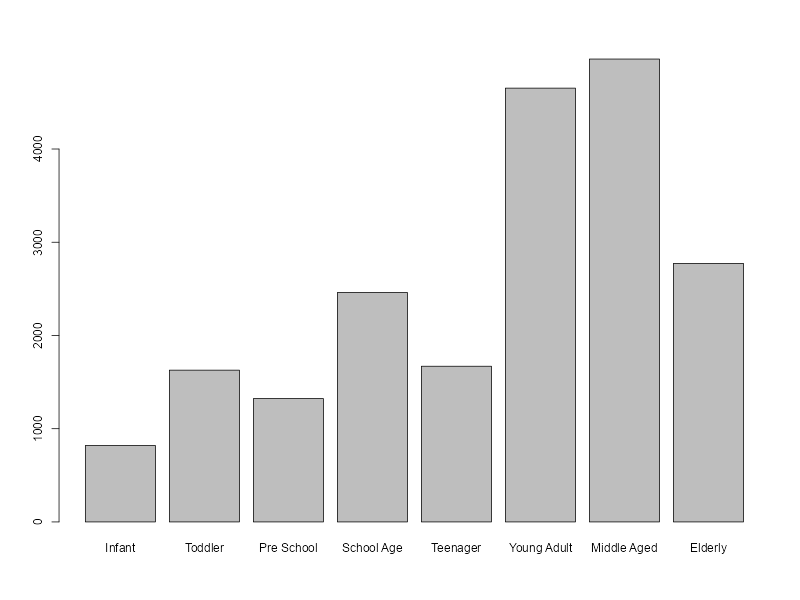

In [141]:
### manipulating levels or creating levels for a variable
nhanes |> 
  select(Gender, Race1, Age, Education, Weight, Height) |> 
  mutate(Age_category = case_when(
    Age == 0 ~ 'Infant', 
    Age %in% 1:3 ~ 'Toddler',
    Age %in% 4:6 ~ 'Pre School',
    Age %in% 7:12 ~ 'School Age',
    Age %in% 13:17 ~ 'Teenager',
    Age %in% 18:39 ~ 'Young Adult',
    Age %in% 40:64 ~ 'Middle Aged',
    Age >= 65 ~ 'Elderly',
    .default = 'Unknown'
  )) |> 
  mutate(Age_category = fct_relevel(Age_category, 'Infant', 'Toddler', 'Pre School', 'School Age', 'Teenager', 'Young Adult', 'Middle Aged', 'Elderly')) |> 
  select(Age_category) |> table() |> barplot()

In [152]:
nhanes |> 
  select(Age, Gender, Race1, Weight, Height, Diastolic=BPDiaAve, Systolic = BPSysAve) |> 
  mutate(Hypertension = case_when(
    Diastolic >= 90 | Systolic >= 140 ~ 'Hypertensive', 
    Diastolic <= 50 & Systolic <= 100 ~ 'Hypotensive', 
    .default = 'Normal'
  ))

# A tibble: 20,293 × 8
     Age Gender Race1    Weight Height Diastolic Systolic Hypertension
   <dbl> <chr>  <chr>     <dbl>  <dbl>     <dbl>    <dbl> <chr>       
 1    34 male   White      87.4   165.        85      113 Normal      
 2     4 male   Other      17     105.        NA       NA Normal      
 3    16 male   Black      72.3   181.        59      109 Normal      
 4    10 male   Black      39.8   148.        41       93 Hypotensive 
 5    60 female Black     117.    166         68      150 Hypertensive
 6    26 male   Mexican    97.6   173         49      104 Normal      
 7    49 female White      86.7   168.        75      112 Normal      
 8     1 female White       9.4    NA         NA       NA Normal      
 9    10 male   Hispanic   26     140.        53      108 Normal      
10    80 male   White      79.1   174.        43      139 Normal      
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
##splirtting variables using separate
nhanes |> 
  select(ID, SurveyYr, Sex=Gender, Race=Race1, Age, Education, HHIncome) |> 
  separate(HHIncome, c('HHincome_lower', 'HHincome_upper'), '-') |> 
  mutate(
    HHincome_lower = as.numeric(HHincome_lower), 
    HHincome_upper = as.numeric(HHincome_upper)
  )

Warning messages:
1: Expected 2 pieces. Missing pieces filled with `NA` in 2892 rows [33, 39, 41, 94, 96, 99, 111, 112, 121, 122, 135, 142, 143, 148, 157, 158, 170,
173, 174, 178, ...]. 
2: There was 1 warning in `mutate()`.
ℹ In argument: `HHincome_lower = as.numeric(HHincome_lower)`.
Caused by warning:
! NAs introduced by coercion 


# A tibble: 20,293 × 8
      ID SurveyYr Sex    Race       Age Education      HHincome_lower HHincome_upper
   <dbl> <chr>    <chr>  <chr>    <dbl> <chr>                   <dbl>          <dbl>
 1 51624 2009_10  male   White       34 High School             25000          34999
 2 51625 2009_10  male   Other        4 NA                      20000          24999
 3 51626 2009_10  male   Black       16 NA                      45000          54999
 4 51627 2009_10  male   Black       10 NA                      20000          24999
 5 51628 2009_10  female Black       60 High School             10000          14999
 6 51629 2009_10  male   Mexican     26 9 - 11th Grade          25000          34999
 7 51630 2009_10  female White       49 Some College            35000          44999
 8 51631 2009_10  female White        1 NA                      35000          44999
 9 51632 2009_10  male   Hispanic    10 NA                      65000          74999
10 51633 2009_10  male   White       80 So

In [162]:
?unite

In [166]:
nhanes |> 
  select(ID, SurveyYr, Sex=Gender, Race=Race1, Age, Education, HHIncome) |> 
  unite('Demographic', c(Race, Sex), sep=' ')

# A tibble: 20,293 × 6
      ID SurveyYr Demographic     Age Education      HHIncome   
   <dbl> <chr>    <chr>         <dbl> <chr>          <chr>      
 1 51624 2009_10  White male       34 High School    25000-34999
 2 51625 2009_10  Other male        4 NA             20000-24999
 3 51626 2009_10  Black male       16 NA             45000-54999
 4 51627 2009_10  Black male       10 NA             20000-24999
 5 51628 2009_10  Black female     60 High School    10000-14999
 6 51629 2009_10  Mexican male     26 9 - 11th Grade 25000-34999
 7 51630 2009_10  White female     49 Some College   35000-44999
 8 51631 2009_10  White female      1 NA             35000-44999
 9 51632 2009_10  Hispanic male    10 NA             65000-74999
10 51633 2009_10  White male       80 Some College   15000-19999
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows